# Tutorial: Initial Contact Detection

**Author:** Masoud Abedinifar

**Last update:** Mon 27 May 2024

## Learning objectives
By the end of this tutorial, you will be able to: 

- Load data from a recording that belongs to one of the available datasets.
- Apply the Paraschiv-Ionescu initial contact detection algorithm to accelerometer data.  
- Visualize the results of initial contact detection algorithm.
- Extract temporal parameters for the detected strides.
- Interpret the parameters for further analysis.

# Paraschiv Initial Contact Detection

This example can be referenced by citing the package.

The example illustrates how the Paraschiv initial contact detection algorithm is used to detect initial contacts using body acceleration recorded with a triaxial accelerometer worn or fixed on the lower back. The initial contact detection algorithm is implemented in the main module [`ngmt.modules.icd._paraschiv`](https://github.com/neurogeriatricskiel/NGMT/tree/main/ngmt/modules/icd/_paraschiv.py). This algorithm is based on the research of Paraschiv-Ionescu et al [`1`-`2`].

The algorithm takes accelerometer data as input, specifically the vertical acceleration component, and processes each specified gait sequence independently. The algorithm requires the start and duration of each gait sequence, in the format provided by the Paraschiv-Ionescu gait sequence detection algorithm ([`ngmt.modules.gsd._paraschiv`](https://github.com/neurogeriatricskiel/NGMT/tree/main/ngmt/modules/gsd/_paraschiv.py)). The sampling frequency of the accelerometer data is also required as another input. Detected gait sequence information is provided as a DataFrame, which consists of the onset and duration of the gait sequences. For each gait sequence, the algorithm applies the Signal Decomposition algorithm for initial contacts. The algorithm handles multiple gait sequences and ensures uniform output by padding the initial contacts lists with NaN values to match the length of the sequence with the maximum number of initial contacts detected among all sequences. Finally, initial contacts information is provided as a DataFrame with columns `onset`, `event_type`, `tracking_systems`, and `tracked_points`.

#### References
[`1`] Paraschiv-Ionescu et al. (2019). Locomotion and cadence detection using a single trunk-fixed accelerometer: validity for children with cerebral palsy in daily life-like conditions. Journal of NeuroEngineering and Rehabilitation, 16(1), 24. https://doi.org/10.1186/s12984-019-0494-z

[`2`] Paraschiv-Ionescu et al. (2020). Real-world speed estimation using a single trunk IMU: methodological challenges for impaired gait patterns. Annual International Conference of the IEEE Engineering in Medicine and Biology Society. IEEE Engineering in Medicine and Biology Society. https://doi.org/10.1109/EMBC44109.2020.9176281

## Import Libraries
The necessary libraries such as numpy, matplotlib.pyplot, dataset (keepcontrol), Paraschiv-Ionescu gait sequence detection, and Paraschiv-Ionescu initial contact detection algorithms are imported from their corresponding modules. Make sure that you have all the required libraries and modules installed before running this code. You also may need to install the `ngmt` library and its dependencies if you haven't already.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from ngmt.datasets import keepcontrol
from ngmt.modules.gsd import ParaschivIonescuGaitSequenceDetection
from ngmt.modules.icd import ParaschivIonescuInitialContactDetection
from ngmt.config import cfg_colors

## Data Preparation
To implement the Paraschiv-Ionescu initial contact detection algorithm, we load example data from keepcontrol dataset.

The Keep Control dataset derived from the [Keep Control](https://www.keep-control.eu/) project and is a Industrial Academic Initial Training Network working towards specific diagnosis and treatment of age-related gait and balance deficits. Part of the dataset was made publicly available on [figshare](https://figshare.com/articles/dataset/Full-body_mobility_data_to_validate_inertial_measurement_unit_algorithms_in_healthy_and_neurological_cohorts/20238006), and it was published as Warmerdam *et al*., Data, 2022, Full-Body Mobility Data to Validate Inertial Measurement Unit Algorithms in Healthy and Neurological Cohorts, doi: [10.3390/data7100136](https://doi.org/10.3390/data7100136).

For this dataset a simple load function is provided to load the data into the NGMT dataclasses.

In [ ]:
# The 'file_path' variable holds the absolute path to the data file
file_path = (
    r"\Keep Control\Data\sub-pp002_task-tug_tracksys-imu_motion.tsv"
)

# In this example, we use "imu" as tracking_system and "pelvis" as tracked points.
tracking_sys = "imu"
tracked_points = {tracking_sys: ["pelvis"]}

# The 'keepcontrol.load_recording' function is used to load the data from the specified file_path
recording = keepcontrol.load_recording(
    file_name=file_path, tracking_systems=[tracking_sys], tracked_points=tracked_points
)

# Load lower back acceleration data
acceleration_data = recording.data[tracking_sys][
    ["pelvis_ACCEL_x", "pelvis_ACCEL_y", "pelvis_ACCEL_z"]
]

# Get the corresponding sampling frequency directly from the recording
sampling_frequency = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"] == "pelvis_ACCEL_x"
]["sampling_frequency"].values[0]

## Visualisation of the Data
The raw acceleration data including components of x, y and z axis is represented.

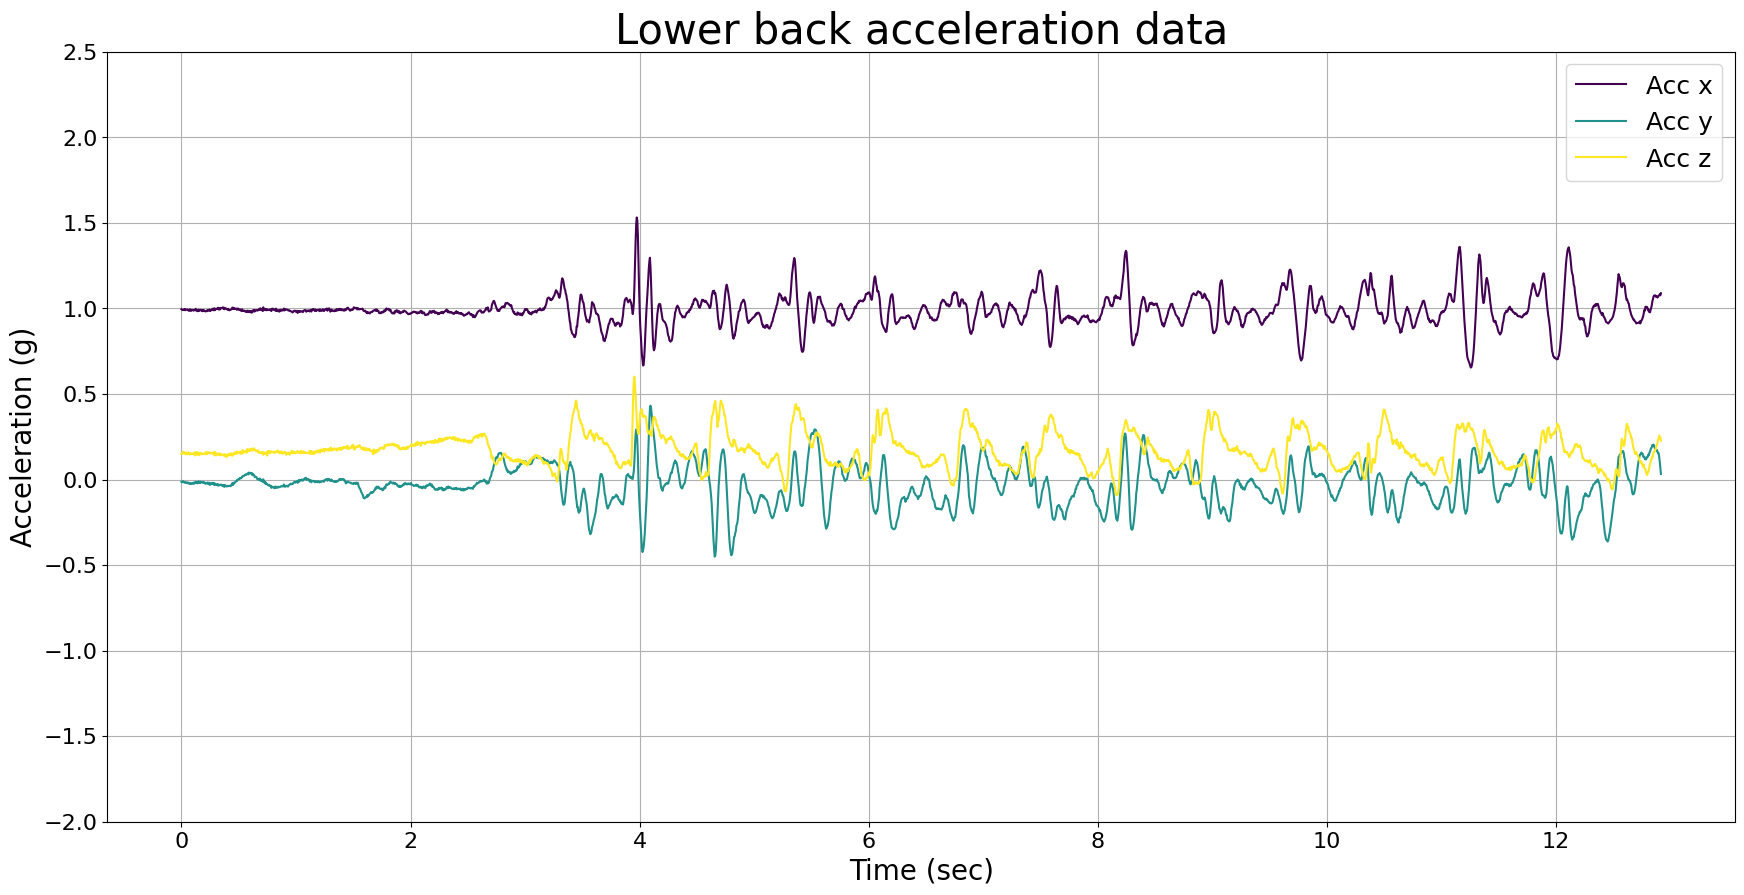

In [39]:
# Plot acceleration data
fig = plt.figure(figsize=(21, 10))

# Get colors
colors = cfg_colors["raw"]

for i in range(3):
    plt.plot(
        np.arange(len(acceleration_data[f"pelvis_ACC_{chr(120 + i)}"])) / sampling_frequency,
        acceleration_data[f"pelvis_ACC_{chr(120 + i)}"],
        color=colors[i],
        label=f"Acc {'xyz'[i]}",
    )

plt.title("Lower back acceleration data", fontsize=30)
plt.ylabel("Acceleration (g)", fontsize=20)
plt.xlabel("Time (sec)", fontsize=20)
plt.legend(loc="upper right", fontsize=18)
plt.ylim(-2, 2.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")
plt.show()

## Applying Paraschiv-Ionescu Initial Contact Detection Algorithm
Now, we are running Paraschiv-Ionescu initial contact detection algorithm from icd module [`NGMT.ngmt.modules.icd._paraschiv.ParaschivIonescuInitialContactDetection`](https://github.com/neurogeriatricskiel/NGMT/tree/main/ngmt/modules/icd/_paraschiv.py) to detect initial contacts throughout the detected gait sequences. For this purpose, we have to first apply Paraschiv-Ionescu gait sequences detection algorithm to identify gait sequences using acceleration data. The gait sequences are detected by Paraschiv gait sequence detection ([`NGMT.ngmt.modules.gsd._paraschiv.ParaschivIonescuGaitSequenceDetection`](https://github.com/neurogeriatricskiel/NGMT/tree/main/ngmt/modules/gsd/_paraschiv.py)).

Then, in order to apply Paraschiv-Ionescu initial contact detection algorithm, an instance of the ParaschivIonescuInitialContactDetection class is created using the constructor, `ParaschivIonescuInitialContactDetection()`. The `icd` variable holds the instance, allowing us to access its methods. The inputs of Paraschiv-Ionescu initial contact detection algorithm are as follows:

- **Input Data:** `data` consist of accelerometer data (N, 3) for the x, y, and z axes in pandas Dataframe format.
- **Gait Sequences:** `gait_sequences`, consist of gait sequences detected by Paraschiv gait sequence detection ([`NGMT.ngmt.modules.gsd._paraschiv.ParaschivIonescuGaitSequenceDetection`](https://github.com/neurogeriatricskiel/NGMT/tree/main/ngmt/modules/gsd/_paraschiv.py)).
- **Sampling Frequency:** `sampling_freq_Hz` is the sampling frequency of the data, defined in Hz, with a default value of 100 Hz.
- **Vertical Acceleration Column Name:** `v_acc_col_name` is the column name that corresponds to the vertical acceleration.



In [43]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect to detect gait sequences
gsd = gsd.detect(
    data=acceleration_data, sampling_freq_Hz=sampling_frequency, plot_results=False
)

# Now, use Paraschiv-Ionescu initial contact detection algortihm to find initial and final contacts within detected gait sequences.
icd = ParaschivIonescuInitialContactDetection()

# Call the initial contact detection using icd.detect
icd = icd.detect(
    data=acceleration_data,
    gait_sequences=gsd.gait_sequences_,
    sampling_freq_Hz=sampling_frequency,
    v_acc_col_name="pelvis_ACC_x"
)

# Print initial contacts and final contacts information
print(f"detected events:", icd.initial_contacts_)

1 gait sequence(s) detected.
detected events:      onset       event_type  duration tracking_systems
0    3.850  initial contact         0             None
1    4.150    final contact         0             None
2    4.450  initial contact         0             None
3    4.825    final contact         0             None
4    5.200  initial contact         0             None
5    5.550    final contact         0             None
6    5.875  initial contact         0             None
7    6.225    final contact         0             None
8    6.600  initial contact         0             None
9    6.950    final contact         0             None
10   7.350  initial contact         0             None
11   7.700    final contact         0             None
12   8.075  initial contact         0             None
13   8.400    final contact         0             None
14   8.800  initial contact         0             None
15   9.125    final contact         0             None
16   9.500  initial

## Visualization of the Event

In the following, the raw data of the lower back sensor is plotted with the detected events. The events are plotted as vertical lines. The events are:

- **Gait onset [s]**: Start of the gait sequence
- **Gait duration [s]**: Duration of the gait sequence
- **Initial contacts [s]**: Initial contacts
- **Final contacts [s]**: Final contacts

The gait onset is represented with the vertical green line and the grey area represents the duration of gait sequence detected by the algorithm. The vertical dashed red and blue lines are representing detected initial contacts and final contacts within first gait sequence.

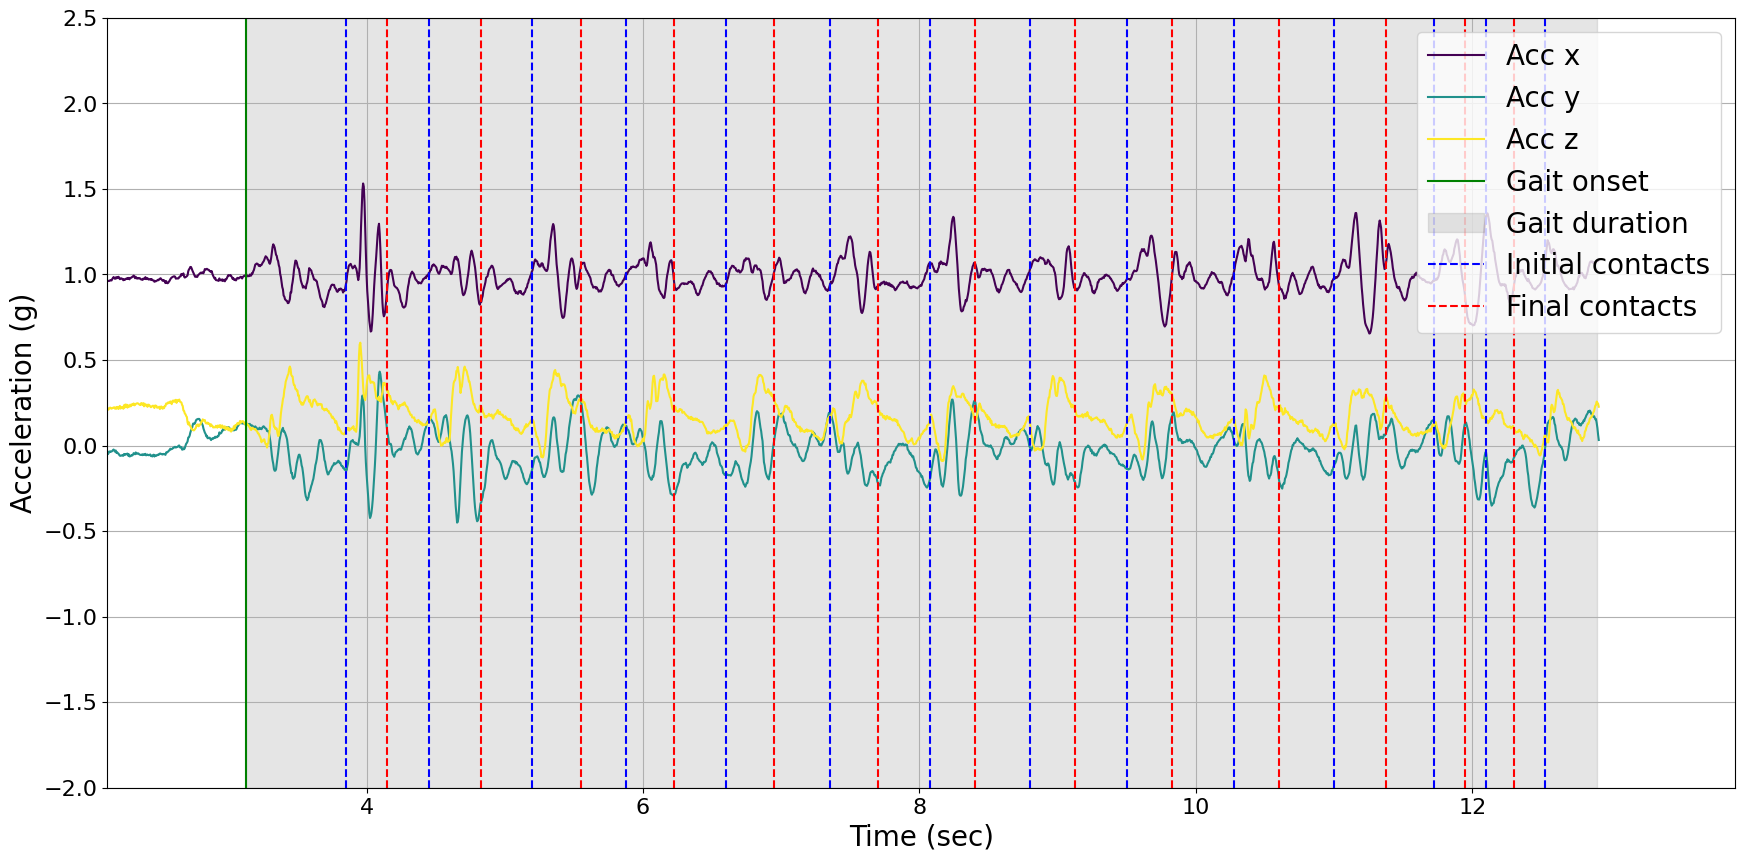

In [45]:
# Access the first detected gait sequence
first_gait_sequence = gsd.gait_sequences_[gsd.gait_sequences_["event_type"] == "gait sequence"].iloc[0]

# Initial contacts within the first gait sequence
ic_within_gait = icd.initial_contacts_[
    (icd.initial_contacts_["onset"].between(
        first_gait_sequence["onset"],
        first_gait_sequence["onset"] + first_gait_sequence["duration"],
    )) & (icd.initial_contacts_["event_type"] == "initial contact")
]

# Final contacts within the first gait sequence
fc_within_gait = icd.initial_contacts_[
    (icd.initial_contacts_["onset"].between(
        first_gait_sequence["onset"],
        first_gait_sequence["onset"] + first_gait_sequence["duration"],
    )) & (icd.initial_contacts_["event_type"] == "final contact")
]

# Plot
fig = plt.figure(figsize=(21, 10))

# Plot raw acceleration data
for i in range(3):
    plt.plot(
        np.arange(len(acceleration_data[f"pelvis_ACC_{chr(120 + i)}"])) / sampling_frequency,
        acceleration_data[f"pelvis_ACC_{chr(120 + i)}"],
        color=colors[i],
        label=f"Acc {'xyz'[i]}",
    )

# Plot the detected first gait sequence
plt.axvline(first_gait_sequence["onset"], color="g", label="Gait onset")
plt.axvspan(
    first_gait_sequence["onset"],
    first_gait_sequence["onset"] + first_gait_sequence["duration"],
    alpha=0.2,
    color="gray",
    label="Gait duration",
)

# Plot the initial contacts within the first gait sequence
for ic_time in ic_within_gait["onset"]:
    plt.axvline(ic_time, color="blue", linestyle="--", label="Initial contacts")

# Plot the final contacts within the first gait sequence
for fc_time in fc_within_gait["onset"]:
    plt.axvline(fc_time, color="red", linestyle="--", label="Final contacts")

# Customize plot
start_limit = first_gait_sequence["onset"] - 1
end_limit = first_gait_sequence["onset"] + first_gait_sequence["duration"] + 1
plt.xlim(start_limit, end_limit)
plt.ylim(-2, 2.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Acceleration (g)", fontsize=20)
plt.xlabel("Time (sec)", fontsize=20)
plt.legend(loc="upper right", fontsize=18)
plt.grid(visible=None, which="both", axis="both")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=20, loc="upper right")
plt.show()


## Extraction of Temporal Parameters

In the following, the temporal parameters for each stride are extracted. The object is needed for calculating the temporal parameters. These parameters are calculated based on inital contact and final contact events.

The temporal parameters are:
- **stride time [s]**: Time for a stride [s]
- **swing time [s]**: Time for the swing phase [s].
- **stance time [s]**: Time for the stance phase [s].


In [47]:
# Call the temporal parameters object for extracting the temporal parameters
icd.temporal_parameters()

# Print temporal parameters for each stride
print(icd.parameters_)

           stride time [s]  swing time [s]  stance time [s]
stride id                                                  
0                    1.350           0.375            0.975
1                    1.425           0.325            1.100
2                    1.400           0.375            1.025
3                    1.475           0.400            1.075
4                    1.475           0.375            1.100
5                    1.450           0.400            1.050
6                    1.425           0.375            1.050
7                    1.475           0.450            1.025
8                    1.500           0.400            1.100
9                    1.450           0.350            1.100
10                   1.100           0.150            0.950
11                   0.800           0.225            0.575
